In [1]:
 import pandas as pd
 import numpy as np
 from sklearn.model_selection import train_test_split
 from sklearn.linear_model import LinearRegression
 from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
 import matplotlib.pyplot as plt


In [3]:
data = pd.read_csv('HousePriceTrain.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
# Memeriksa apakah ada nilai dalam dataset yang "kosong" atau "NaN"
print(data.isnull().values.any())
print(data.isnull().sum())

True
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [7]:
data = data.fillna(data.mean(numeric_only=True))
print(data.isnull().sum())

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64


In [13]:
data.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [16]:
# Memilih fitur (features) dan target
features = ['OverallQual', 'GrLivArea', 'GarageCars','GarageArea','TotalBsmtSF', 'FullBath', 'YearBuilt']
X = data[features]
y = data['SalePrice']

In [21]:
 # Bagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", y_train.shape)
print("Shape of Y_test:", y_test.shape)

Shape of X_train: (1168, 7)
Shape of X_test: (292, 7)
Shape of Y_train: (1168,)
Shape of Y_test: (292,)


In [22]:
 # Inisialisasi model
 model = LinearRegression()
 # Latih model menggunakan data latih
 model.fit(X_train, y_train)
 # Buat prediksi menggunakan data uji
 y_pred = model.predict(X_test)

In [23]:
 # Hitung metrik evaluasi
 mse = mean_squared_error(y_test, y_pred)
 rmse = np.sqrt(mse)
 r2 = r2_score(y_test, y_pred)
 mape = mean_absolute_percentage_error(y_test, y_pred)
 print("Mean Squared Error (MSE):", mse)
 print("Root Mean Squared Error (RMSE):", rmse)
 print("R-squared (R2):", r2)
 print("Mean Absolute Percentage Error :", mape)


Mean Squared Error (MSE): 1572343803.5778513
Root Mean Squared Error (RMSE): 39652.79061526252
R-squared (R2): 0.7950095261783574
Mean Absolute Percentage Error : 0.15160491195301415


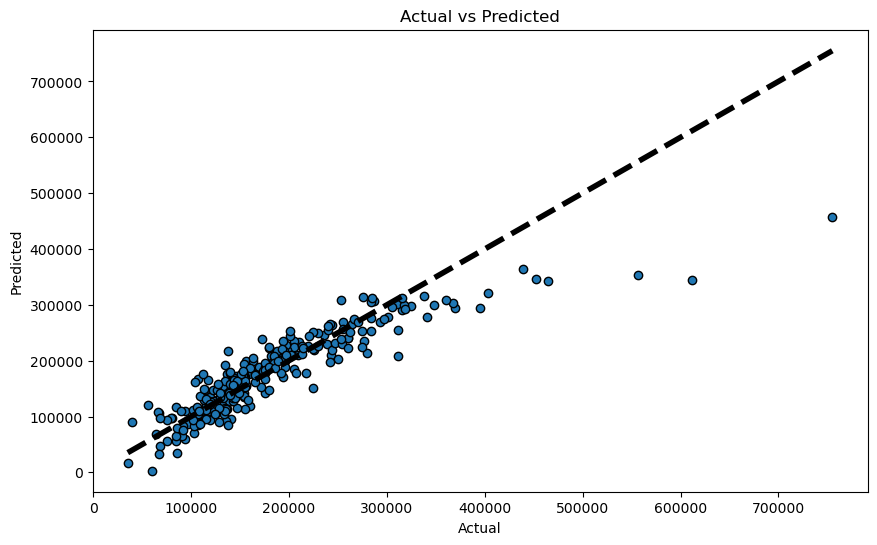

In [24]:
 # Visualisasi hasil prediksi vs. nilai aktual
 plt.figure(figsize=(10, 6))
 plt.scatter(y_test, y_pred, edgecolors=(0, 0, 0))
 plt.plot([y_test.min(), y_test.max()], [y_test.min(), 
y_test.max()], 'k--', lw=4)
 plt.xlabel('Actual')
 plt.ylabel('Predicted')
 plt.title('Actual vs Predicted')
 plt.show()